# 과제 4 — 데이터 증강 성능 비교

## 합성 데이터 생성

- **Class 0**: 가로 막대 이미지
- **Class 1**: 세로 막대 이미지
- **훈련셋**: 도형이 항상 중앙 → 증강 없이는 중앙 픽셀에 과적합
- **테스트셋**: 도형이 랜덤 위치 → 위치 불변성이 있어야 맞출 수 있음

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

torch.manual_seed(42)
np.random.seed(42)

IMG_SIZE = 28

def make_shape(label, cx, cy):
    img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    if label == 0:  # 가로 막대
        img[max(0,cy-2):min(IMG_SIZE,cy+2), max(0,cx-8):min(IMG_SIZE,cx+8)] = 1.0
    else:           # 세로 막대
        img[max(0,cy-8):min(IMG_SIZE,cy+8), max(0,cx-2):min(IMG_SIZE,cx+2)] = 1.0
    img += np.random.normal(0, 0.1, img.shape).astype(np.float32)
    return np.clip(img, 0, 1)

# 훈련: 도형이 항상 중앙
cx0, cy0 = IMG_SIZE // 2, IMG_SIZE // 2
X_train = np.array([make_shape(i % 2, cx0, cy0) for i in range(200)])
y_train = np.array([i % 2 for i in range(200)], dtype=np.int64)

# 테스트: 도형이 랜덤 위치
X_test = np.array([make_shape(i % 2, np.random.randint(10, IMG_SIZE-10),
                                      np.random.randint(10, IMG_SIZE-10)) for i in range(2000)])
y_test = np.array([i % 2 for i in range(2000)], dtype=np.int64)

print(f'훈련: {len(X_train)}장 (중앙 고정), 테스트: {len(X_test)}장 (랜덤 위치)')
print('클래스: 0=가로막대, 1=세로막대')

훈련: 200장 (중앙 고정), 테스트: 2000장 (랜덤 위치)
클래스: 0=가로막대, 1=세로막대


## Dataset, 모델, 학습 함수 정의

In [2]:
class ShapeDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = torch.from_numpy(X[:, np.newaxis])  # (N, 1, H, W)
        self.y = torch.from_numpy(y)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.transform:
            x = self.transform(x)
        return x, self.y[idx]


# 이동 증강: 도형 위치를 랜덤하게 변경 → 위치 불변성 학습
transform_aug = T.RandomAffine(degrees=0, translate=(0.35, 0.35))

train_ds_base = ShapeDataset(X_train, y_train)
train_ds_aug  = ShapeDataset(X_train, y_train, transform=transform_aug)
test_ds       = ShapeDataset(X_test,  y_test)

train_ldr_base = DataLoader(train_ds_base, batch_size=32, shuffle=True)
train_ldr_aug  = DataLoader(train_ds_aug,  batch_size=32, shuffle=True)
test_ldr       = DataLoader(test_ds, batch_size=64)


def build_model():
    return nn.Sequential(
        nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(32 * 14 * 14, 64), nn.ReLU(),
        nn.Linear(64, 2)
    )


def train_and_eval(model, train_loader, test_loader, epochs=30):
    optimizer = optim.Adam(model.parameters())
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        train_correct = 0
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            train_correct += (model(X_b).argmax(1) == y_b).sum().item()
        train_acc = train_correct / len(train_loader.dataset)

        model.eval()
        with torch.no_grad():
            test_correct = sum((model(X_b).argmax(1) == y_b).sum().item()
                               for X_b, y_b in test_loader)
        test_acc = test_correct / len(test_loader.dataset)

        if (epoch + 1) % 5 == 0:
            print(f'  epoch {epoch+1:2d}/{epochs}  훈련: {train_acc:.4f}  테스트: {test_acc:.4f}')

    return test_acc

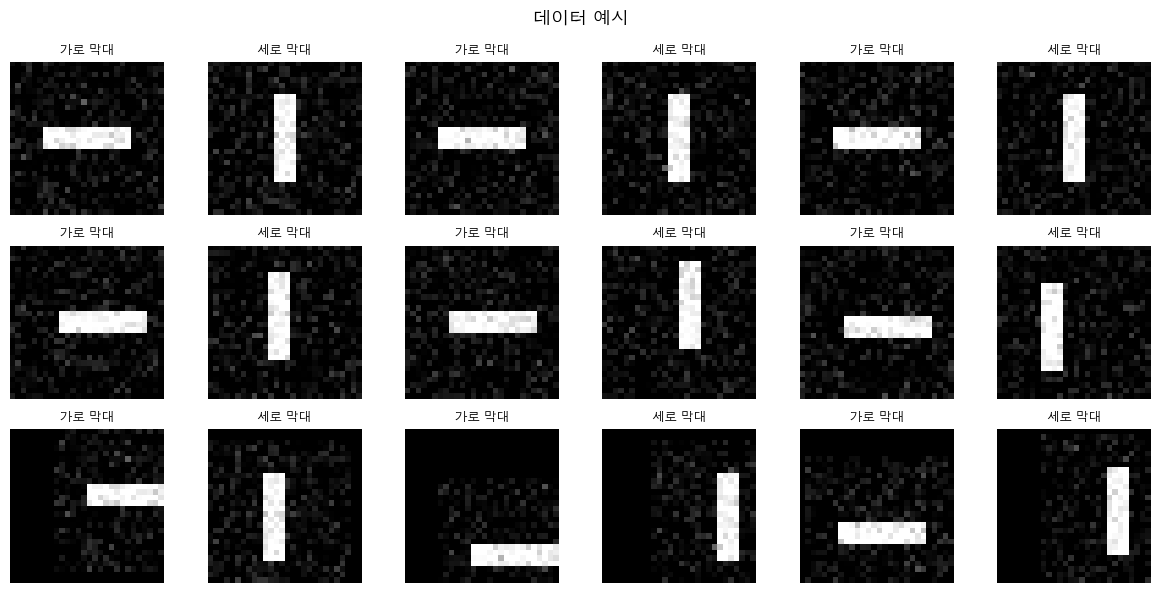

In [3]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(3, 6, figsize=(12, 6))
labels_name = ['가로 막대', '세로 막대']

# 훈련 데이터 (중앙 고정)
for i in range(6):
    axes[0, i].imshow(X_train[i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(labels_name[y_train[i]], fontsize=9)
    axes[0, i].axis('off')

# 테스트 데이터 (랜덤 위치)
for i in range(6):
    axes[1, i].imshow(X_test[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(labels_name[y_test[i]], fontsize=9)
    axes[1, i].axis('off')

# 증강 적용 예시
aug_ds = ShapeDataset(X_train[:6], y_train[:6], transform=transform_aug)
for i in range(6):
    img, label = aug_ds[i]
    axes[2, i].imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[2, i].set_title(labels_name[label], fontsize=9)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('훈련 (중앙)', fontsize=10)
axes[1, 0].set_ylabel('테스트 (랜덤)', fontsize=10)
axes[2, 0].set_ylabel('증강 적용', fontsize=10)

plt.suptitle('데이터 예시', fontsize=13)
plt.tight_layout()
plt.show()

## 증강 없이 학습

In [4]:
print('=== 증강 없이 학습 ===')
model_base = build_model()
acc_base   = train_and_eval(model_base, train_ldr_base, test_ldr)
print(f'\n증강 없이 — 테스트 정확도: {acc_base:.4f}')

=== 증강 없이 학습 ===
  epoch  5/30  훈련: 1.0000  테스트: 0.8495
  epoch 10/30  훈련: 1.0000  테스트: 0.8520
  epoch 15/30  훈련: 1.0000  테스트: 0.8515
  epoch 20/30  훈련: 1.0000  테스트: 0.8510
  epoch 25/30  훈련: 1.0000  테스트: 0.8470
  epoch 30/30  훈련: 1.0000  테스트: 0.8450

증강 없이 — 테스트 정확도: 0.8450


## 증강 적용 후 학습

In [5]:
print('=== 증강 적용 후 학습 ===')
model_aug = build_model()
acc_aug   = train_and_eval(model_aug, train_ldr_aug, test_ldr)
print(f'\n증강 적용 — 테스트 정확도: {acc_aug:.4f}')

=== 증강 적용 후 학습 ===
  epoch  5/30  훈련: 0.8700  테스트: 0.6865
  epoch 10/30  훈련: 0.9600  테스트: 1.0000
  epoch 15/30  훈련: 0.9800  테스트: 1.0000
  epoch 20/30  훈련: 1.0000  테스트: 1.0000
  epoch 25/30  훈련: 1.0000  테스트: 1.0000
  epoch 30/30  훈련: 1.0000  테스트: 1.0000

증강 적용 — 테스트 정확도: 1.0000


## 성능 비교

In [6]:
print(f'증강 없이:  {acc_base:.4f}')
print(f'증강 적용:  {acc_aug:.4f}')
print(f'차이:       {acc_aug - acc_base:+.4f}')

증강 없이:  0.8450
증강 적용:  1.0000
차이:       +0.1550
